# *Signatures of Compact Object Mergers Inside Stars in AGN Disks*

#### Cantiello et al. (in prep.)

This notebook reproduces **every figure** and the **key quantitative results** of the paper.
All of the physics is implemented in the accompanying `agn_cee` Python package; the cells below
just build the immortal-star model once and call the package's figure functions, with a short
explanation of the physical input and references for each figure.

**Contents**
- §0 Setup
- §1 Structure of an immortal AGN star — *Fig. 1*
- §2 A single compact object — *Figs. 2–4*
- §3 An embedded binary black hole — *Figs. 5–6*
- §4 Gravitational-wave observables — *Figs. 7–8*
- §A Appendix: the gas-hardening model ladder — *Fig. 9*
- §5 Verification of the numbers quoted in the paper

**Figure ↔ file ↔ function map** (filenames match the `\includegraphics` calls in the manuscript):

| Paper figure | File | Function |
|---|---|---|
| Fig. 1 | `fig1_structure.pdf` | `figures.fig_structure` |
| Fig. 2 | `fig3_caseA_inspiral.pdf` | `figures.fig_inspiral` |
| Fig. 3 | `fig9_spiral_trajectories.pdf` | `review.fig_true_trajectories` |
| Fig. 4 | `fig2_caseA_powers.pdf` | `figures.fig_power` |
| Fig. 5 | `fig4_caseB_powers.pdf` | `review.fig_power_caseB` |
| Fig. 6 | `fig8_energy_deposition.pdf` | `review.fig_energy_deposition` |
| Fig. 7 | `fig6_dephasing.pdf` | `figures.fig_dephasing` |
| Fig. 8 | `fig7_characteristic_strain.pdf` | `review.fig_characteristic_strain` |
| Fig. 9 (App. B) | `fig5_hardening_ladder.pdf` | `review.fig_hardening_ladder` |

## §0 Setup

We import the package and build the immortal-star structure model from the MESA profile in `data/`.
The model stitches the hydrostatic stellar interior (from MESA) to an analytic accretion stream
extending out to the Bondi radius, and exposes interpolators for $\rho(r)$, $c_s(r)$ and $M_{\rm enc}(r)$.

In [1]:
import os
import numpy as np
import matplotlib
from agn_cee import (constants as c, structure, physics, inspiral, bbh,
                     detectors, observability, rates, figures, review)

Msun, Rsun = c.MSUN, c.RSUN

# Build the fiducial immortal-star model (M ~ 773 Msun) used throughout the paper.
model = structure.build_model(structure.DEFAULT_PROFILE)
print("Immortal star:  M_* = %.0f Msun,  R_shock = %.1f Rsun,  rho_c = %.1f g/cm^3,  R_Bondi = %.2e Rsun"
      % (model.m_star/Msun, model.r_shock/Rsun, model.rho_c, model.r_bondi/Rsun))

FIGDIR = "figures"
os.makedirs(FIGDIR, exist_ok=True)
def savefig(fig, name):
    "Save a figure to figures/<name> exactly as used in the manuscript."
    fig.savefig(os.path.join(FIGDIR, name))
    print("wrote", os.path.join(FIGDIR, name))

Immortal star:  M_* = 773 Msun,  R_shock = 12.5 Rsun,  rho_c = 15.9 g/cm^3,  R_Bondi = 2.95e+06 Rsun


## §1 Structure of an immortal AGN star — Fig. 1

The fiducial model is a $M_\star\simeq773\,M_\odot$ immortal star (Cantiello, Jermyn & Lin 2021),
computed with MESA. Its hydrostatic core has radius $R_\star\simeq12.5\,R_\odot$ and central
density $\rho_{\rm c}\simeq16\,{\rm g\,cm^{-3}}$; outside the accretion shock at the surface, an
analytic free-falling stream ($\rho\propto r^{-3/2}$) carries gas in from the Bondi radius
($R_{\rm B}\simeq3\times10^{6}\,R_\odot\simeq0.07$ pc), where it matches the ambient AGN-disk
conditions.

*References:* Cantiello, Jermyn & Lin (2021); Dittmann et al. (2025).

wrote figures/fig1_structure.pdf


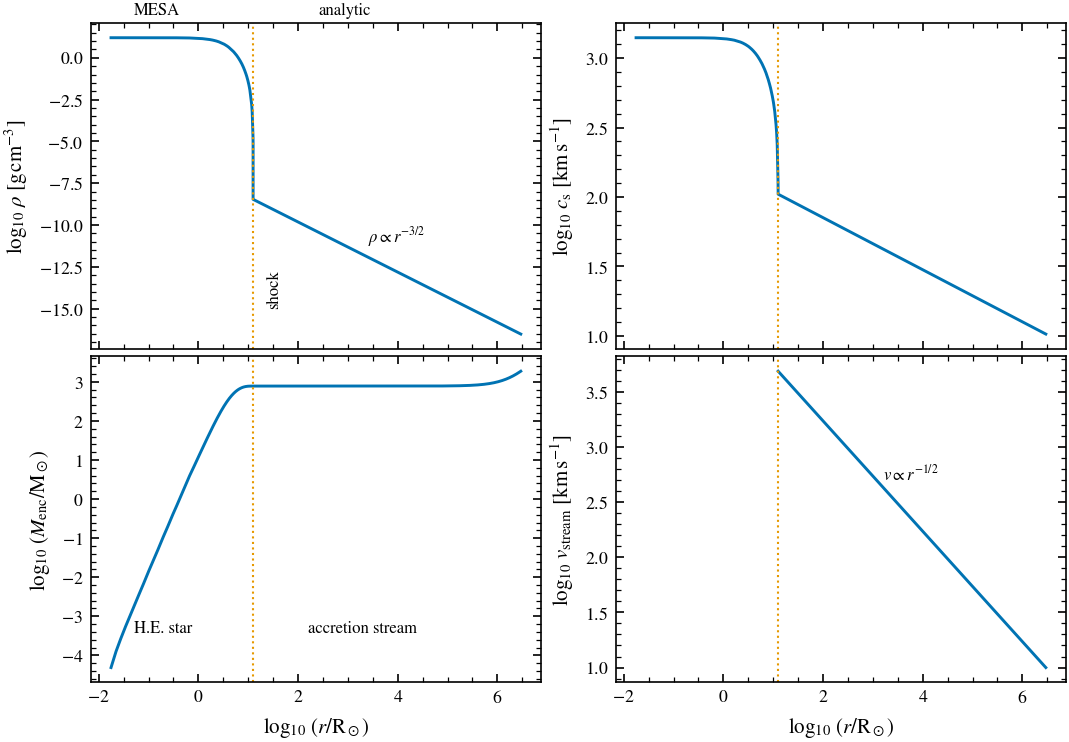

In [2]:
fig = figures.fig_structure(model)
savefig(fig, "fig1_structure.pdf")

## §2 A single compact object

A compact object captured by an immortal sinks through the envelope, losing orbital energy and
angular momentum to gaseous **dynamical friction**, **Bondi–Hoyle–Lyttleton (BHL) accretion drag**,
and **gravitational-wave (GW) emission**.

### Fig. 2 — spiral-in trajectory

Because the BH orbits the enclosed mass $M_{\rm enc}(r)$ rather than a point mass, we integrate the
loss of orbital angular momentum, $\dot L = -(L_{\rm DF}+L_{\rm acc}+L_{\rm GW})/\Omega(r)$. A
$10\,M_\odot$ BH captured at the surface reaches the core in $\sim0.1$ yr; heavier objects sink
faster, and the timescale is set by the tenuous outer envelope.

wrote figures/fig3_caseA_inspiral.pdf


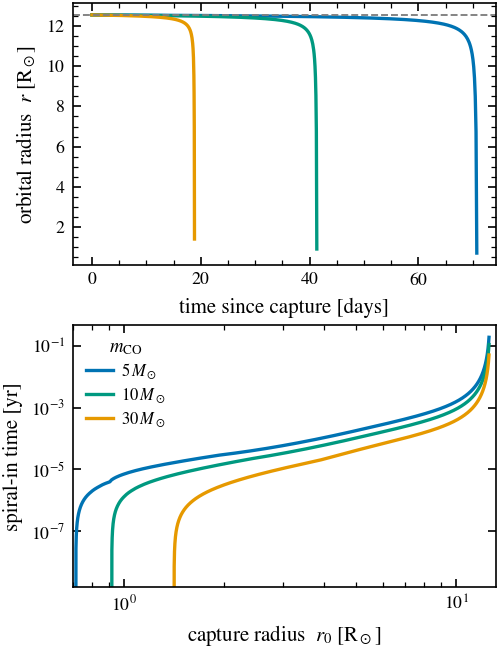

In [3]:
fig = figures.fig_inspiral(model, masses=(5, 10, 30))
savefig(fig, "fig3_caseA_inspiral.pdf")

### Fig. 3 — real spiral-in trajectories

The genuine integrated paths $(r\cos\phi,\,r\sin\phi)$ with the true accumulated orbital phase
$\phi(t)=\int\Omega\,dt$ — the non-schematic version of the two infall problems. *(a)* A single CO
sinking from the surface to the core (linear radius): it orbits the enclosed mass $M_{\rm enc}(r)$,
lingers near the tenuous surface, then plunges; pink marks $r<r(M_\star=m_{\rm BH})$ where the
test-particle treatment fails. *(b)* The same with a second BH held at the centre, followed to merger
(log radius): BH2 winds $\sim\!3000$ times, crowding into the gas–GW stall near a few$\,\times10^{-3}R_\odot$
before the final GW plunge to the ISCO. The pink disk marks $R_{\rm BHL}/r>1$ ($r\lesssim0.6\,R_\odot$),
the 3D-breakdown region. Colour is time since capture.

wrote figures/fig9_spiral_trajectories.pdf


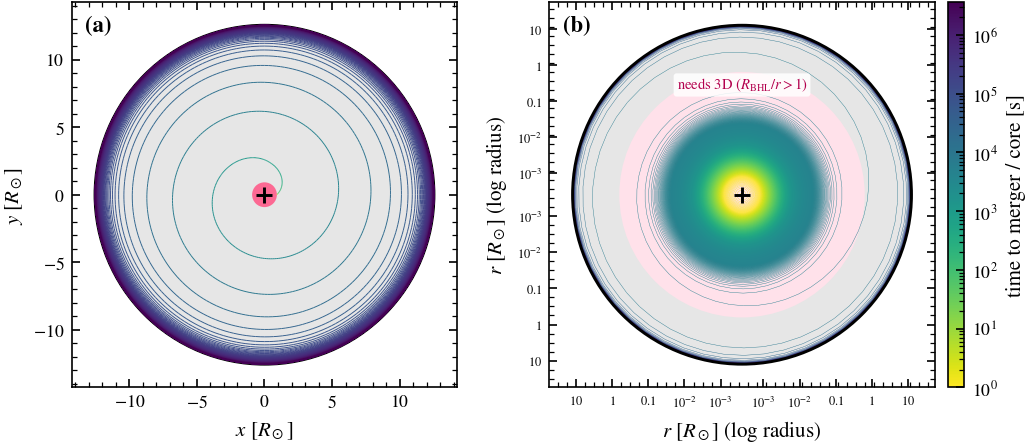

In [4]:
fig = review.fig_true_trajectories(model)
savefig(fig, "fig9_spiral_trajectories.pdf")   # Fig. 3 in the manuscript

### Fig. 4 — energy-loss channels vs. separation

Power extracted by each channel for a $10\,M_\odot$ BH (BH2) spiralling toward a second, equal-mass
BH (BH1) held at the stellar center — the binary configuration used to place the GW channel, which
needs a companion to radiate, alongside the gas-drag channels (top axis: GW frequency, with the
LISA/DECIGO/LVK bands; right axis: GW characteristic strain at 100 Mpc). The dynamical-friction force
uses the circular-orbit prescriptions of Ostriker (1999) and Kim & Kim (2007), with the nonlinear
correction of Kim (2010); the accretion drag is $\dot M_{\rm BHL}\,v$; the GW luminosity is from
Peters (1964). The bottom panel shows the Mach number and $v_{\rm K}/c$, with BH2's orbital speed
$v_{\rm K}(a)=\sqrt{G\,[m_1+m_2+M_\star(<a)]/a}$ including the enclosed stellar mass.

*References:* Ostriker (1999); Kim & Kim (2007); Kim (2010); Edgar (2004); Peters (1964).

wrote figures/fig2_caseA_powers.pdf


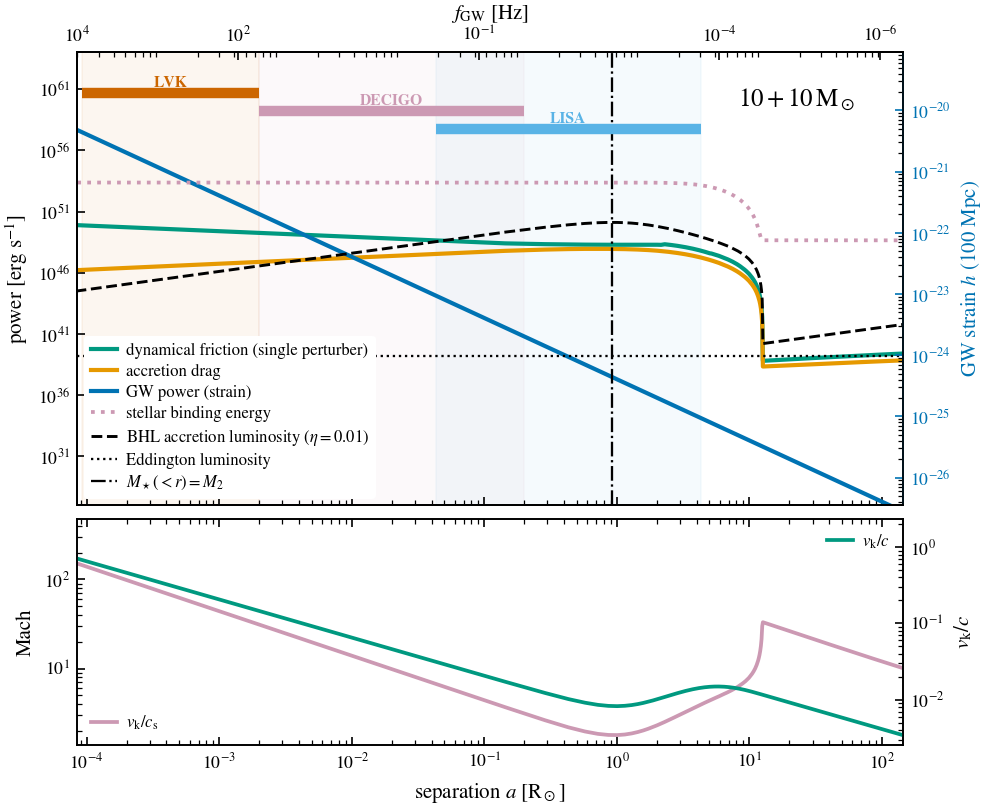

In [5]:
fig = figures.fig_power(model)          # BH2 around central BH1, d = 100 Mpc
savefig(fig, "fig2_caseA_powers.pdf")

## §3 An embedded binary black hole

Once a BBH forms in the core, its internal orbit hardens through the same gas channels (now
supplemented by GW emission). We bracket the hardening with a ladder of dynamical-friction
prescriptions (see Appendix); the fiducial model combines the nonlinear self-wake (Kim 2010) with the
double-perturber companion wake of Kim, Kim & Sánchez-Salcedo (2008, KKSS08).

### Fig. 5 — energy-loss channels for the internal BBH orbit

Gas drag (gray band = model range, solid = fiducial) vs. GW power for the internal $10+10\,M_\odot$
orbit. Gas hardening dominates GW emission by many orders of magnitude over the separations that set
the residence time. The lower panel shows the validity diagnostics ($R_{\rm BHL,i}/r_i$,
$R_{\rm B,BBH}/a$, $M_{\rm gas}(<a)/M_{\rm BBH}$): the independent point-perturber picture fails where
these exceed unity.

*References:* Kim, Kim & Sánchez-Salcedo (2008); Kim (2010); Peters (1964).

wrote figures/fig4_caseB_powers.pdf


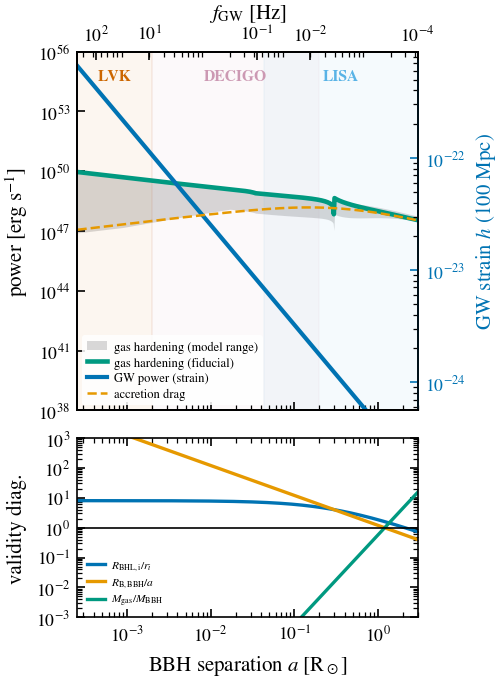

In [6]:
fig = review.fig_power_caseB(model)     # 10+10 Msun, d = 100 Mpc
savefig(fig, "fig4_caseB_powers.pdf")   # this is Fig. 5 in the manuscript

### Fig. 6 — energy deposited into the star

Cumulative orbital energy delivered to the stellar gas as the fiducial $10+10\,M_\odot$ binary hardens,
$E_{\rm gas}(<a)=\int L_{\rm gas}\,dt$, compared with the star's gravitational binding energy
$|\Omega|$ and its *net* binding energy $|\Omega|-E_{\rm int}$ (reduced by the internal energy of the
radiation-dominated, near-$n{=}3$ envelope). The deposited energy reaches the net binding energy near
$a\simeq7\times10^{-3}R_\odot$ — i.e. even a fiducial-mass BBH can deposit a dynamically significant
amount of energy before GW emission takes over.

wrote figures/fig8_energy_deposition.pdf


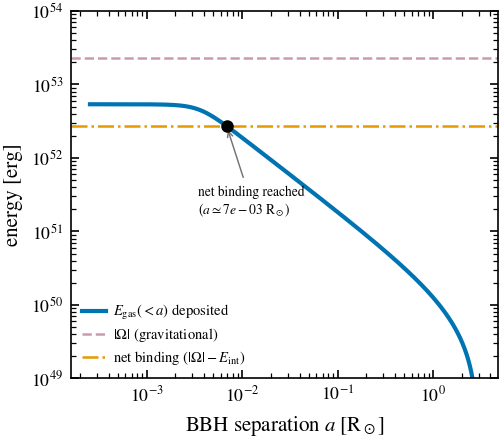

In [7]:
fig = review.fig_energy_deposition(model)
savefig(fig, "fig8_energy_deposition.pdf")   # this is Fig. 6 in the manuscript

## §4 Gravitational-wave observables

### Fig. 7 — dephasing relative to a vacuum inspiral

The number of cycles lost relative to vacuum, $\delta N(>\!f)=N_{\rm V}-N_{\rm star}$, for the
fiducial binary and several core gas conditions. In the LISA band the binary plunges (no
quasi-stationary inspiral), so the milli-Hz $\delta N$ is a plunge rather than a measurable phase
offset; near the LVK band the binary merges nearly as in vacuum. The sound speed uses the
Chandrasekhar $\Gamma_1$ mixture for the radiation+gas envelope.

wrote figures/fig6_dephasing.pdf


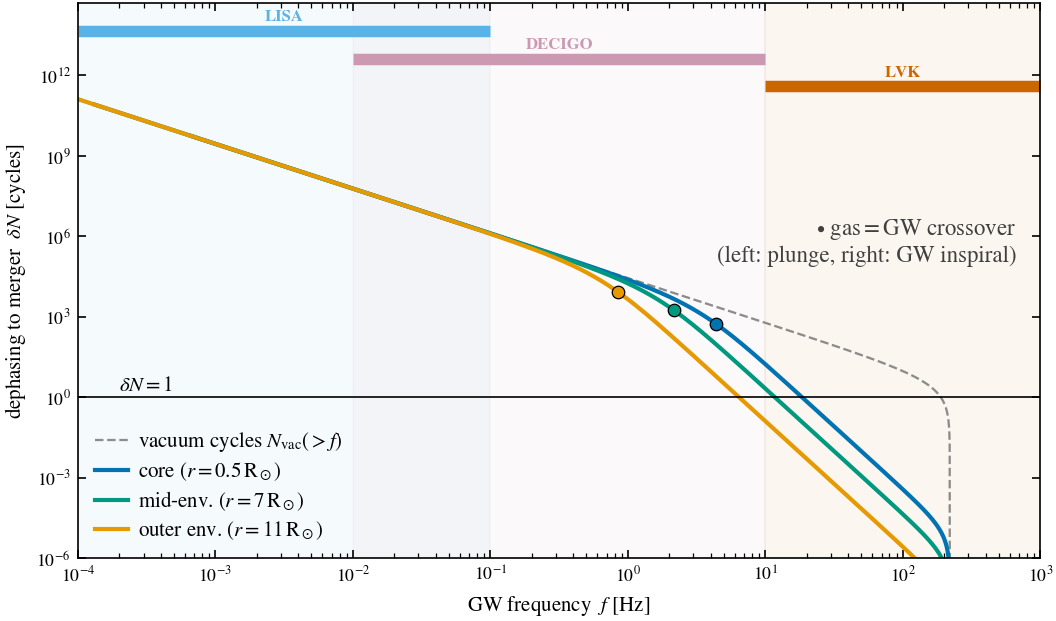

In [8]:
fig = figures.fig_dephasing(model)
savefig(fig, "fig6_dephasing.pdf")   # this is Fig. 7 in the manuscript

### Fig. 8 — characteristic strain across the detector bands

Characteristic strain $h_{\rm c}(f)=A\sqrt{\min(f^2/\dot f,\,fT_{\rm obs})}$ ($T_{\rm obs}=4$ yr) of a
gas-hardened $10+10\,M_\odot$ binary at 100 Mpc (solid = fiducial, band = model ladder), against the
sky-averaged LISA, DECIGO and LVK sensitivity curves. Gas hardening erases the milli-Hz inspiral
cycles, suppressing $h_{\rm c}$ by several orders of magnitude in the LISA band; the track recovers
toward vacuum at deci-Hz and enters the LVK band near merger — a deci-Hz/DECIGO phenomenon.

*References:* Robson, Cornish & Liu (2019) [LISA]; Yagi & Seto (2011), Kawamura et al. (2011)
[DECIGO]; LVK O3 strain ASD [LVK].

wrote figures/fig7_characteristic_strain.pdf


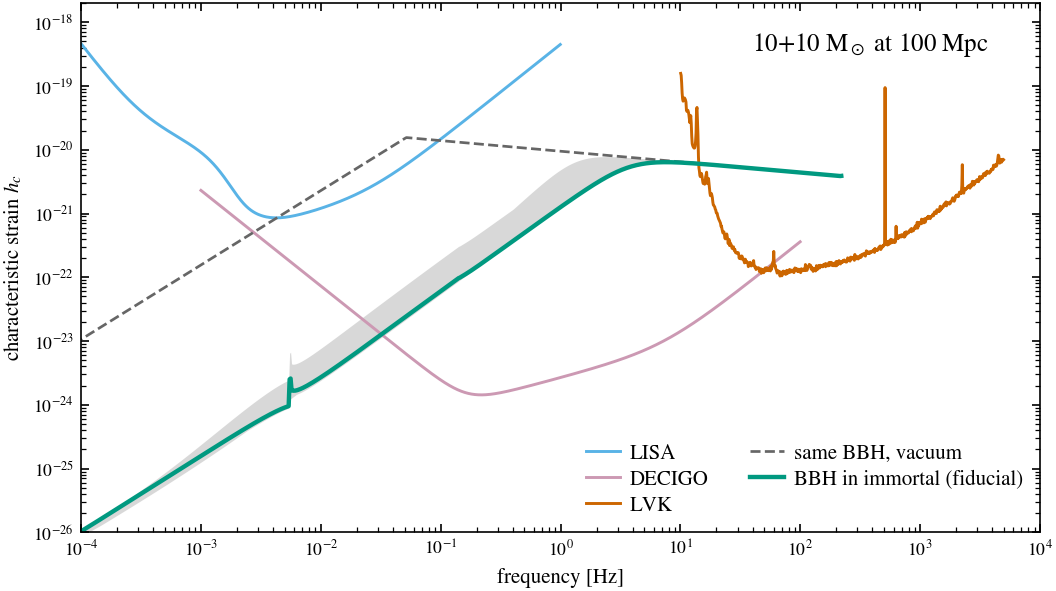

In [9]:
fig = review.fig_characteristic_strain(model)   # 10+10 Msun at 100 Mpc
savefig(fig, "fig7_characteristic_strain.pdf")  # this is Fig. 8 in the manuscript

## §A Appendix B — the gas-hardening model ladder (Fig. 9)

The ratio of the gas-driven to GW-driven hardening rate, $|\dot a_{\rm gas}|/|\dot a_{\rm GW}|$, for the
six prescriptions in the ladder. The companion-wake term uses the verbatim KKSS08 azimuthal drag
coefficient $I_{2,\phi}(\mathcal{M})$. Gas hardening dominates GW emission across the inspiral for the
trusted prescriptions; only the pure-linear rung approaches the gas–GW parity line.

*References:* Kim, Kim & Sánchez-Salcedo (2008); MacLeod et al. (2017); De et al. (2020).

wrote figures/fig5_hardening_ladder.pdf


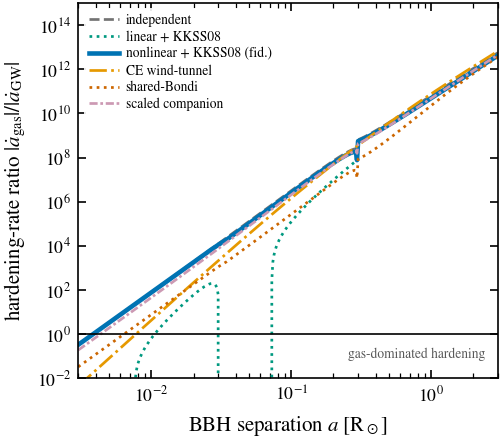

In [10]:
fig = review.fig_hardening_ladder(model)
savefig(fig, "fig5_hardening_ladder.pdf")   # this is Fig. 9 (Appendix B) in the manuscript

## §5 Verification of the numbers quoted in the paper

The cell below recomputes the key quantitative results, so a reader can check the values stated in the
text directly against the code.

In [11]:
print("STRUCTURE")
print("  M_* = %.0f Msun,  R_shock = %.2f Rsun,  rho_c = %.2f g/cm^3" %
      (model.m_star/Msun, model.r_shock/Rsun, model.rho_c))
print("  R_Bondi = %.2e Rsun = %.3f pc" % (model.r_bondi/Rsun, model.r_bondi/3.086e18))

print("\nCASE A  (single 10 Msun BH, captured at the surface)")
sol = inspiral.spiral_in_time(model, 10*Msun, model.r_shock)
print("  spiral-in time surface -> core: %.3f yr" % (sol["t_total"]/3.156e7))

print("\nCASE B  (internal 10+10 Msun orbit) -- hardening model ladder, merger time from a0 = Rsun")
cs = review.cs_at(review.sound_speed_prescriptions(), 0.5*Rsun, "cs_gas")
for mdl in range(6):
    t = review.merger_time_model(10*Msun, 10*Msun, Rsun, model.rho_c, cs, model=mdl)
    hr = t/3600.0
    s = "%.2f hr" % hr if hr < 48 else "%.2g yr" % (t/3.156e7)
    print("  Model %d  %-38s t_merge = %s" % (mdl, review.HARDENING_MODELS[mdl], s))
print("  vacuum (GW-only) from a0 = Rsun: %.2g yr" % (physics.t_merge_gw(10*Msun, 10*Msun, Rsun)/3.156e7))

print("\nENERGETICS")
be = review.binding_energy_components()
print("  |Omega| = %.2e erg,  E_int = %.2e erg,  net binding = %.2e erg (%.0f%% of |Omega|)"
      % (be["omega"], be["E_int"], be["net_binding"], 100*be["net_binding"]/be["omega"]))
e = review.gas_energy_deposited(10*Msun, 10*Msun, 3*Rsun, model.rho_c, cs)
i = int(np.argmin(np.abs(e["E_gas"] - be["net_binding"])))
print("  E_gas(<a) reaches the net binding energy at a = %.1e Rsun" % (e["a"][i]/Rsun))
t_dyn = np.sqrt(model.r_shock**3/(c.G*model.m_star))
print("  stellar dynamical time sqrt(R^3/GM) = %.2f hr" % (t_dyn/3600.0))

print("\nGW OBSERVABLES (10+10 Msun)")
f0, A0 = physics.gw_strain(10*Msun, 10*Msun, Rsun, 100*c.MPC)
print("  GW frequency at a = Rsun: %.2f mHz" % (f0*1e3))
snr = observability.snr(10*Msun, 10*Msun, model.rho_c, cs, 100*c.MPC, "LVK", gas=False)
print("  sky-averaged LVK SNR (10+10 at 100 Mpc): %.0f  (~50 quoted in the paper)" % snr)
dN = review.measurable_dephasing(10*Msun, 10*Msun, 5*Rsun, model.rho_c, cs, band=(10.0, 1e3))
print("  LVK-band residual dephasing (gas c_s): %.0f cycles" % dN["resid_max"])

print("\nRATE")
print("  optimistic (n_BBH=20): R ~ 8 Gpc^-3 yr^-1  (~1/3 of the O3 LVK rate)")
print("  likely    (n_BBH=1-2): R ~ 0.4-0.8 Gpc^-3 yr^-1")
print("  => plausible span R ~ 0.4-8 Gpc^-3 yr^-1 (strongly conditional on the disk aspect ratio h)")

STRUCTURE
  M_* = 773 Msun,  R_shock = 12.54 Rsun,  rho_c = 15.93 g/cm^3
  R_Bondi = 2.95e+06 Rsun = 0.067 pc

CASE A  (single 10 Msun BH, captured at the surface)
  spiral-in time surface -> core: 0.113 yr

CASE B  (internal 10+10 Msun orbit) -- hardening model ladder, merger time from a0 = Rsun
  Model 0  independent wake / upper-drag baseline t_merge = 0.97 hr
  Model 1  linear self + KKSS08 companion         t_merge = 2 yr
  Model 2  nonlinear self + KKSS08 (fiducial)     t_merge = 1.06 hr
  Model 3  CE wind-tunnel $C_d$                   t_merge = 6.65 hr
  Model 4  shared-Bondi suppressed                t_merge = 7.49 hr
  Model 5  scaled companion (stress test)         t_merge = 1.52 hr
  vacuum (GW-only) from a0 = Rsun: 7.5e+04 yr

ENERGETICS
  |Omega| = 2.29e+53 erg,  E_int = 2.01e+53 erg,  net binding = 2.72e+52 erg (12% of |Omega|)
  E_gas(<a) reaches the net binding energy at a = 6.9e-03 Rsun
  stellar dynamical time sqrt(R^3/GM) = 0.71 hr

GW OBSERVABLES (10+10 Msun)
  GW 